In [1]:
import parcels
import math
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import scipy

import trajan
import cartopy.crs as ccrs
import cartopy.feature
from datetime import datetime, timedelta
import calculate_distance as c_d

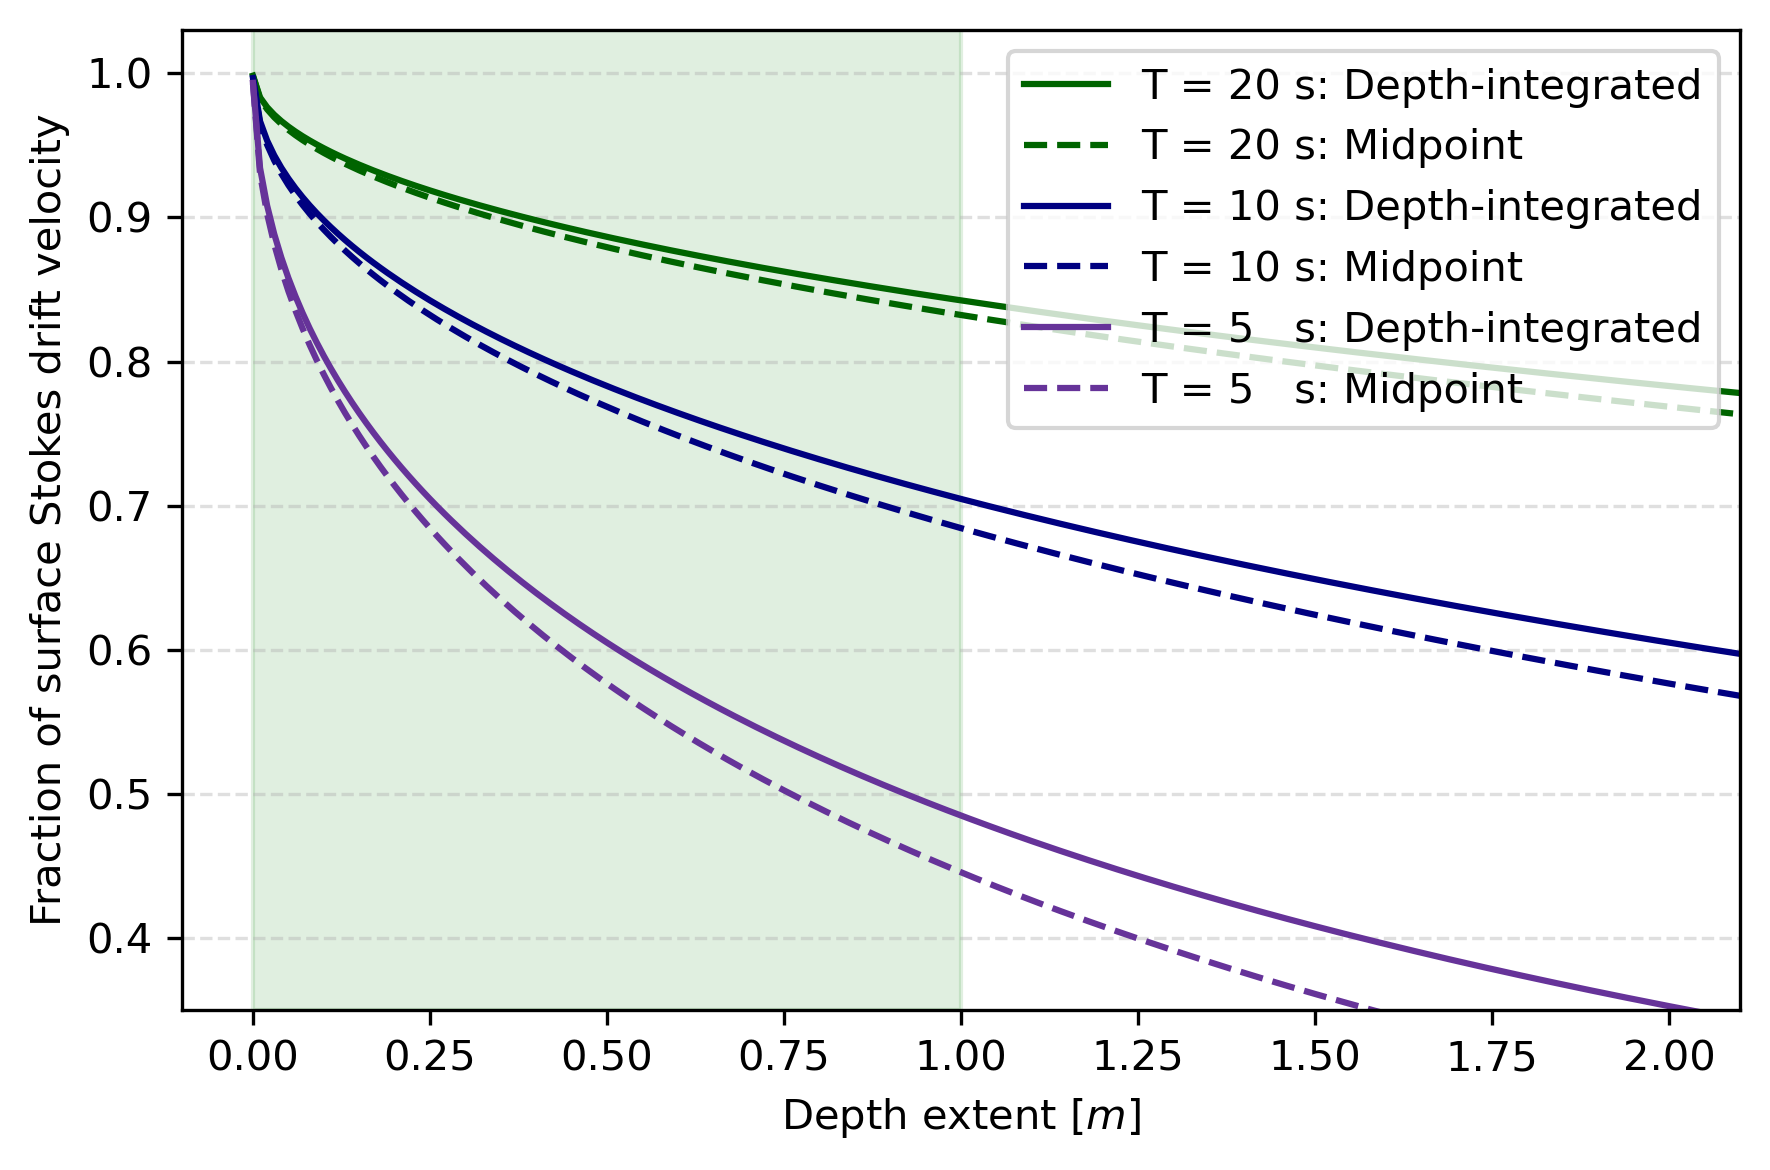

In [9]:
stokes_surface = 1 # [m/s]
delta_z = np.arange(0.0001,2.5,0.01)

T_p = 10
T_p2 = 5
T_p3 = 20
omega_p = 2. * np.pi / T_p
omega_p2 = 2. * np.pi / T_p2
omega_p3 = 2. * np.pi / T_p3

# Peak wave number
k_p = (omega_p ** 2) / 9.81
k_p2 = (omega_p2 ** 2) / 9.81
k_p3 = (omega_p3 ** 2) / 9.81

# Repeated inner term of Eq. (19) - note depth is negative in this formulation, but model depths are positive by convention
# kp_z_2 = 2. * k_p * particle.depth
kp_z_2 = 2. * k_p * delta_z / 2
kp_z_22 = 2. * k_p2 * delta_z / 2
kp_z_23 = 2. * k_p3 * delta_z / 2

# Decay factor in Eq. (19) -- Where beta=1 for the Phillips spectrum
decay = stokes_surface *  np.exp(-kp_z_2) - np.sqrt(np.pi * kp_z_2) * scipy.special.erfc(np.sqrt(kp_z_2))
decay2 = stokes_surface *  np.exp(-kp_z_22) - np.sqrt(np.pi * kp_z_22) * scipy.special.erfc(np.sqrt(kp_z_22))
decay3 = stokes_surface *  np.exp(-kp_z_23) - np.sqrt(np.pi * kp_z_23) * scipy.special.erfc(np.sqrt(kp_z_23))

#Decay function based on Equation A.6 of Li et al. (2017) 
decay_function = 1/(2*k_p) * ( 
                    1 - np.exp(-2*k_p*(delta_z)) 
                    - 2/3 * (1 + np.sqrt(np.pi) * (2*k_p*(delta_z))**(3/2) * scipy.special.erfc(np.sqrt(2*k_p*(delta_z)))  
                    - (1 + 2*k_p*(delta_z)) * np.exp(-2*k_p*(delta_z))   )
                    )

jj = 2 * k_p * np.abs(delta_z)
#Decay function based on Equation A.6 of Li et al. (2017) 
decay_function_ = 1/(2*k_p) * ( 
                    1 - np.exp(-jj) 
                    - 2/3 * (1 + np.sqrt(np.pi) * (jj)**(3/2) * scipy.special.erfc(np.sqrt(jj))  
                    - (1 + jj) * np.exp(-jj)   )
                    )

jj2 = 2 * k_p2 * np.abs(delta_z)
#Decay function based on Equation A.6 of Li et al. (2017) 
decay_function_2 = 1/(2*k_p2) * ( 
                    1 - np.exp(-jj2) 
                    - 2/3 * (1 + np.sqrt(np.pi) * (jj2)**(3/2) * scipy.special.erfc(np.sqrt(jj2))  
                    - (1 + jj2) * np.exp(-jj2)   )
                    )

jj3 = 2 * k_p3 * np.abs(delta_z)
#Decay function based on Equation A.6 of Li et al. (2017) 
decay_function_3 = 1/(2*k_p3) * ( 
                    1 - np.exp(-jj3) 
                    - 2/3 * (1 + np.sqrt(np.pi) * (jj3)**(3/2) * scipy.special.erfc(np.sqrt(jj3))  
                    - (1 + jj3) * np.exp(-jj3)   )
                    )

j = 2 * k_p * np.abs(0)
#Decay function based on Equation A.6 of Li et al. (2017) 
decay_function_0 = 1/(2*k_p) * ( 
                    1 - np.exp(-j) 
                    - 2/3 * (1 + np.sqrt(np.pi) * (j)**(3/2) * scipy.special.erfc(np.sqrt(j))  
                    - (1 + j) * np.exp(-j)   )
                    )

j2 = 2 * k_p2 * np.abs(0)
#Decay function based on Equation A.6 of Li et al. (2017) 
decay_function_02 = 1/(2*k_p2) * ( 
                    1 - np.exp(-j2) 
                    - 2/3 * (1 + np.sqrt(np.pi) * (j2)**(3/2) * scipy.special.erfc(np.sqrt(j2))  
                    - (1 + j2) * np.exp(-j2)   )
                    )

j3 = 2 * k_p3 * np.abs(0)
#Decay function based on Equation A.6 of Li et al. (2017) 
decay_function_03 = 1/(2*k_p3) * ( 
                    1 - np.exp(-j3) 
                    - 2/3 * (1 + np.sqrt(np.pi) * (j3)**(3/2) * scipy.special.erfc(np.sqrt(j3))  
                    - (1 + j3) * np.exp(-j3)   )
                    )

decay_stokes_vel = (stokes_surface * decay_function_ - stokes_surface * decay_function_0 ) / (0 - ( - delta_z ))
decay_stokes_vel2 = (stokes_surface * decay_function_2 - stokes_surface * decay_function_02 ) / (0 - ( -  delta_z ))
decay_stokes_vel3 = (stokes_surface * decay_function_3 - stokes_surface * decay_function_03 ) / (0 - ( - delta_z ))

fig, (ax1) = plt.subplots(1, 1, figsize=(6, 4), dpi = 300)
#Temperature
#plt.axvspan(0, 0.499, color='green', alpha=0.30)
plt.axvspan(0, 1, color='green', alpha=0.12)

ax1.plot(delta_z , decay_stokes_vel3 ,"-", label='T = 20 s: Depth-integrated', color = 'darkgreen')
ax1.plot(delta_z, decay3, "--", label='T = 20 s: Midpoint', color = 'darkgreen')
ax1.plot(delta_z , decay_stokes_vel ,"-", label='T = 10 s: Depth-integrated', color = 'navy')
ax1.plot(delta_z, decay, "--", label='T = 10 s: Midpoint', color = 'navy')
ax1.plot(delta_z , decay_stokes_vel2, "-" , label='T = 5   s: Depth-integrated', color = 'rebeccapurple')
ax1.plot(delta_z, decay2, "--", label='T = 5   s: Midpoint', color = 'rebeccapurple')
ax1.set_xlabel(r'Depth extent [$m$]')
ax1.set_ylabel('Fraction of surface Stokes drift velocity')
#ax1.set_title('Stokes drift over depth extent for different wave periods')
ax1.grid(alpha=0.4, linestyle='--', axis='y')
ax1.set_xlim(-0.1, 2.1)
ax1.set_ylim(0.35,1.03)
ax1.legend(loc='upper right')
#ax1.vlines(1,0.3,1.1, color = 'peru')


plt.tight_layout()
plt.savefig("THESIS_PLOTS/stokes_comp.pdf", format="pdf", bbox_inches="tight")
plt.savefig("THESIS_PLOTS/stokes_comp.png", format="png", bbox_inches="tight")
plt.show()

In [4]:

T_p = np.arange(0.5,40,0.5)
print(T_p)


[ 0.5  1.   1.5  2.   2.5  3.   3.5  4.   4.5  5.   5.5  6.   6.5  7.
  7.5  8.   8.5  9.   9.5 10.  10.5 11.  11.5 12.  12.5 13.  13.5 14.
 14.5 15.  15.5 16.  16.5 17.  17.5 18.  18.5 19.  19.5 20.  20.5 21.
 21.5 22.  22.5 23.  23.5 24.  24.5 25.  25.5 26.  26.5 27.  27.5 28.
 28.5 29.  29.5 30.  30.5 31.  31.5 32.  32.5 33.  33.5 34.  34.5 35.
 35.5 36.  36.5 37.  37.5 38.  38.5 39.  39.5]


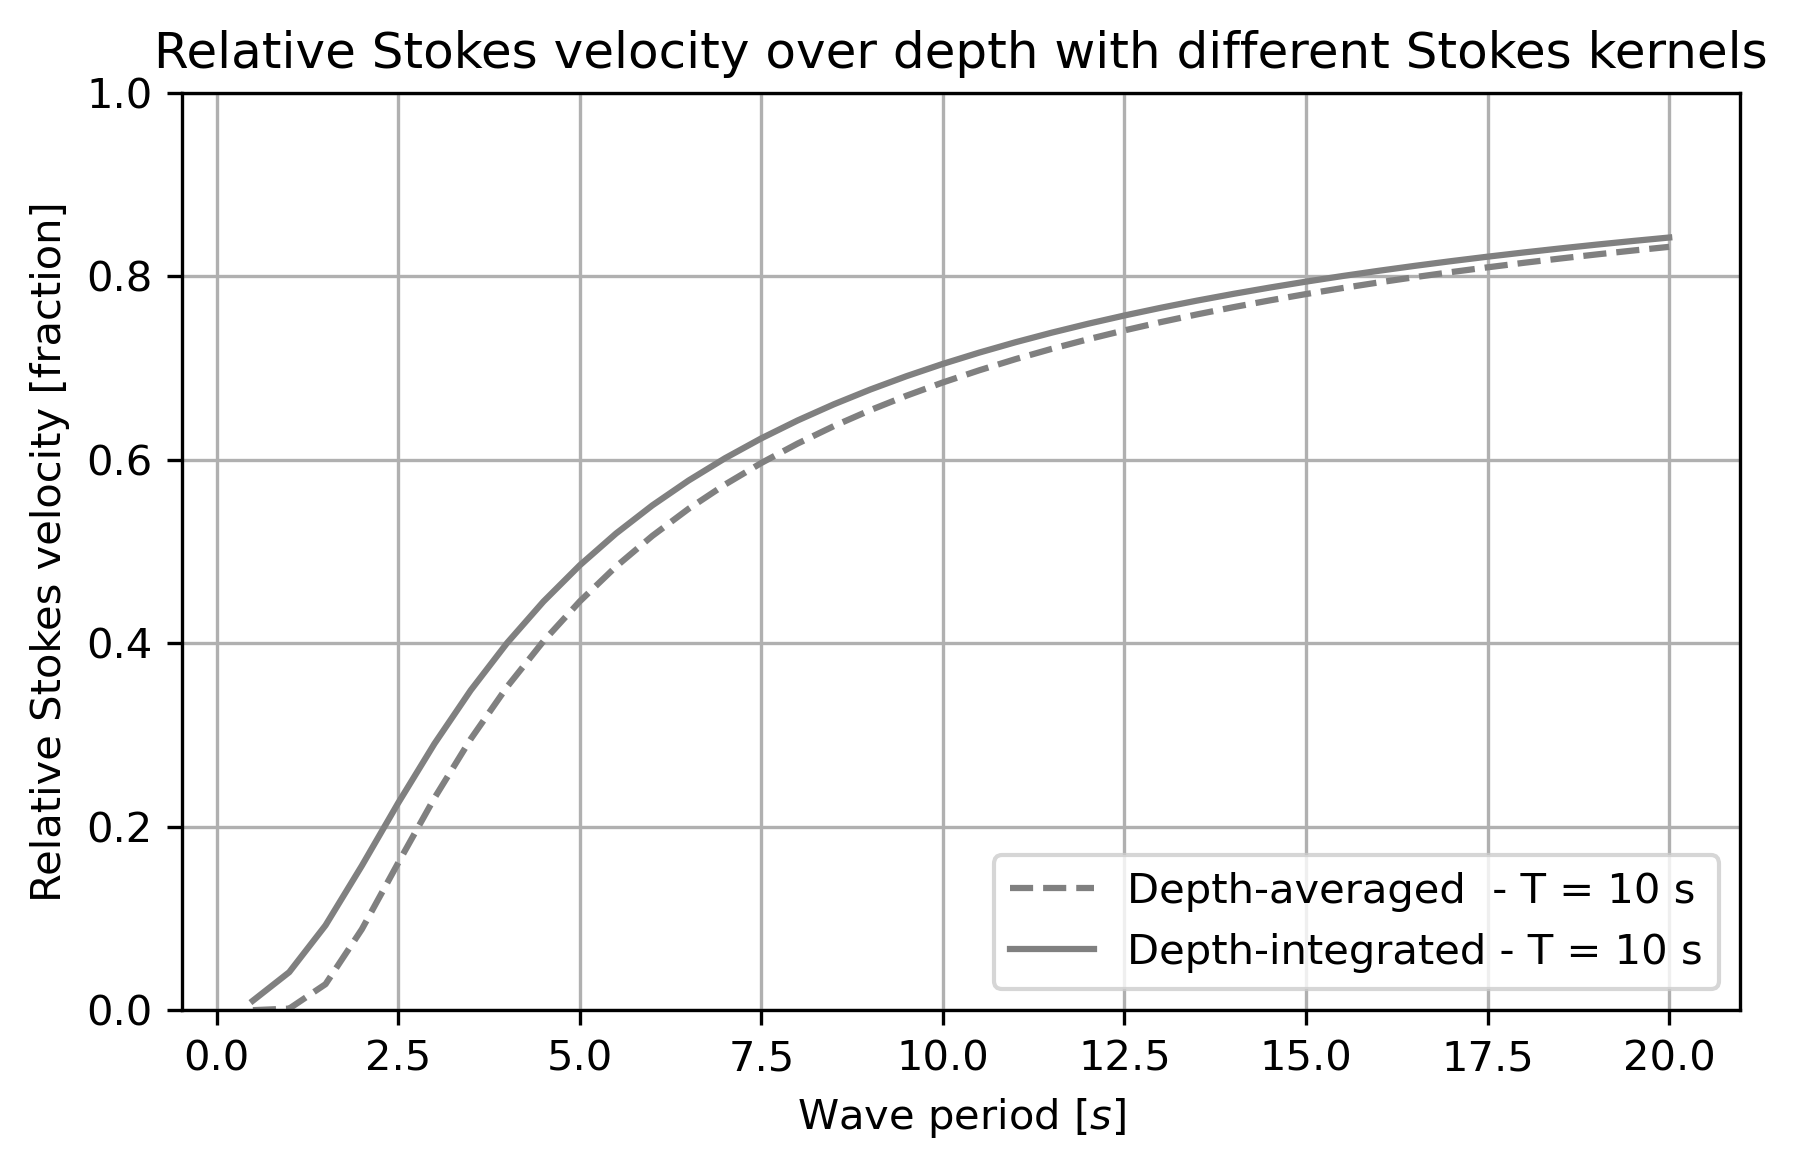

In [5]:
stokes_surface = 1 # [m/s]
delta_z = 1

T_p = np.arange(0.5,20.5,0.5)

#T_p = 10
T_p2 = np.arange(0.5, 20.5,0.5)
T_p3 = 20
omega_p = 2. * np.pi / T_p
omega_p2 = 2. * np.pi / T_p2
omega_p3 = 2. * np.pi / T_p3

# Peak wave number
k_p = (omega_p ** 2) / 9.81
k_p2 = (omega_p2 ** 2) / 9.81
k_p3 = (omega_p3 ** 2) / 9.81

# Repeated inner term of Eq. (19) - note depth is negative in this formulation, but model depths are positive by convention
# kp_z_2 = 2. * k_p * particle.depth
kp_z_2 = 2. * k_p * delta_z / 2
kp_z_22 = 2. * k_p2 * delta_z / 2
kp_z_23 = 2. * k_p3 * delta_z / 2

# Decay factor in Eq. (19) -- Where beta=1 for the Phillips spectrum
decay = stokes_surface *  np.exp(-kp_z_2) - np.sqrt(np.pi * kp_z_2) * scipy.special.erfc(np.sqrt(kp_z_2))
decay2 = stokes_surface *  np.exp(-kp_z_22) - np.sqrt(np.pi * kp_z_22) * scipy.special.erfc(np.sqrt(kp_z_22))
decay3 = stokes_surface *  np.exp(-kp_z_23) - np.sqrt(np.pi * kp_z_23) * scipy.special.erfc(np.sqrt(kp_z_23))

#Decay function based on Equation A.6 of Li et al. (2017) 
decay_function = 1/(2*k_p) * ( 
                    1 - np.exp(-2*k_p*(delta_z)) 
                    - 2/3 * (1 + np.sqrt(np.pi) * (2*k_p*(delta_z))**(3/2) * scipy.special.erfc(np.sqrt(2*k_p*(delta_z)))  
                    - (1 + 2*k_p*(delta_z)) * np.exp(-2*k_p*(delta_z))   )
                    )

jj = 2 * k_p * np.abs(delta_z)
#Decay function based on Equation A.6 of Li et al. (2017) 
decay_function_ = 1/(2*k_p) * ( 
                    1 - np.exp(-jj) 
                    - 2/3 * (1 + np.sqrt(np.pi) * (jj)**(3/2) * scipy.special.erfc(np.sqrt(jj))  
                    - (1 + jj) * np.exp(-jj)   )
                    )

jj2 = 2 * k_p2 * np.abs(delta_z)
#Decay function based on Equation A.6 of Li et al. (2017) 
decay_function_2 = 1/(2*k_p2) * ( 
                    1 - np.exp(-jj2) 
                    - 2/3 * (1 + np.sqrt(np.pi) * (jj2)**(3/2) * scipy.special.erfc(np.sqrt(jj2))  
                    - (1 + jj2) * np.exp(-jj2)   )
                    )

jj3 = 2 * k_p3 * np.abs(delta_z)
#Decay function based on Equation A.6 of Li et al. (2017) 
decay_function_3 = 1/(2*k_p3) * ( 
                    1 - np.exp(-jj3) 
                    - 2/3 * (1 + np.sqrt(np.pi) * (jj3)**(3/2) * scipy.special.erfc(np.sqrt(jj3))  
                    - (1 + jj3) * np.exp(-jj3)   )
                    )

j = 2 * k_p * np.abs(0)
#Decay function based on Equation A.6 of Li et al. (2017) 
decay_function_0 = 1/(2*k_p) * ( 
                    1 - np.exp(-j) 
                    - 2/3 * (1 + np.sqrt(np.pi) * (j)**(3/2) * scipy.special.erfc(np.sqrt(j))  
                    - (1 + j) * np.exp(-j)   )
                    )

j2 = 2 * k_p2 * np.abs(0)
#Decay function based on Equation A.6 of Li et al. (2017) 
decay_function_02 = 1/(2*k_p2) * ( 
                    1 - np.exp(-j2) 
                    - 2/3 * (1 + np.sqrt(np.pi) * (j2)**(3/2) * scipy.special.erfc(np.sqrt(j2))  
                    - (1 + j2) * np.exp(-j2)   )
                    )

j3 = 2 * k_p3 * np.abs(0)
#Decay function based on Equation A.6 of Li et al. (2017) 
decay_function_03 = 1/(2*k_p3) * ( 
                    1 - np.exp(-j3) 
                    - 2/3 * (1 + np.sqrt(np.pi) * (j3)**(3/2) * scipy.special.erfc(np.sqrt(j3))  
                    - (1 + j3) * np.exp(-j3)   )
                    )

decay_stokes_vel = (stokes_surface * decay_function_ - stokes_surface * decay_function_0 ) / (0 - ( - delta_z ))
decay_stokes_vel2 = (stokes_surface * decay_function_2 - stokes_surface * decay_function_02 ) / (0 - ( -  delta_z ))
decay_stokes_vel3 = (stokes_surface * decay_function_3 - stokes_surface * decay_function_03 ) / (0 - ( - delta_z ))

fig, (ax1) = plt.subplots(1, 1, figsize=(6, 4), dpi = 300)
#Temperature
#ax1.plot(T_p, decay3, "--", label='Depth-averaged  - T = 20 s', color = 'tan')
#ax1.plot(T_p , decay_stokes_vel3 ,"-", label='Depth-integrated - T = 20 s', color = 'tan')
ax1.plot(T_p, decay, "--", label='Depth-averaged  - T = 10 s', color = 'grey')
ax1.plot(T_p, decay_stokes_vel ,"-", label='Depth-integrated - T = 10 s', color = 'grey')
#ax1.plot(T_p2, decay2, "--", label='Depth-averaged  - T = 5 s', color = 'darkkhaki')
#ax1.plot(T_p2 , decay_stokes_vel2, "-" , label='Depth-integrated - T = 5 s', color = 'darkkhaki')
ax1.set_xlabel(r'Wave period [$s$]')
ax1.set_ylabel('Relative Stokes velocity [fraction]')
ax1.set_title('Relative Stokes velocity over depth with different Stokes kernels')
ax1.grid()
#ax1.set_xlim(-0.1, 1.6)
ax1.set_ylim(0,1)
ax1.legend(loc='lower right')
#ax1.vlines(1,0.3,1.1, color = 'peru')

plt.tight_layout()
plt.show()

In [25]:
print(math.erfc(0.5))

print(scipy.special.erfc(0.5))

print(math.pi)

print(math.sqrt(math.pi))
print(np.sqrt(np.pi))

0.4795001221869535
0.4795001221869535
3.141592653589793
1.7724538509055159
1.7724538509055159


SargassumParticleAdvectionRK4di_Stokes_driftwind_dragtemperature_from_fieldnitrogen_from_fieldgrowth_temp_based
SargassumParticleAdvectionRK4avg_Stokes_driftwind_dragtemperature_from_fieldnitrogen_from_fieldgrowth_temp_based


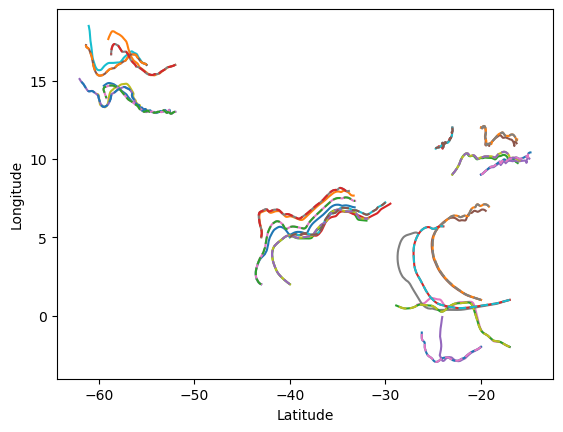

In [3]:
#Opening simulation data files

DSDDI = xr.open_zarr("/storage/shared/oceanparcels/output_data/data_Elena/Simulations_part2/SIM_27aug_decay_functions_stokes_di.zarr")
DSDAV = xr.open_zarr("/storage/shared/oceanparcels/output_data/data_Elena/Simulations_part2/SIM_27aug_decay_functions_stokes_av.zarr")
DSDDI2 = xr.open_zarr("/storage/shared/oceanparcels/output_data/data_Elena/Simulations_part2/SIM_8sept_s_di.zarr")
DSDAV2 = xr.open_zarr("/storage/shared/oceanparcels/output_data/data_Elena/Simulations_part2/SIM_8sept_s_av.zarr")
DSX = xr.open_zarr("/storage/shared/oceanparcels/output_data/data_Elena/Simulations_part2/SIM_11sept_di_check.zarr")
DSX2 = xr.open_zarr("/storage/shared/oceanparcels/output_data/data_Elena/Simulations_part2/SIM_11sept_di_check2.zarr")
DSX3 = xr.open_zarr("/storage/shared/oceanparcels/output_data/data_Elena/Simulations_part2/SIM_11sept_di_check3.zarr")
DSL2 = xr.open_zarr("/storage/shared/oceanparcels/output_data/data_Elena/SIM_part3/SIM_LG_LA_2024_02.zarr").dropna(dim='obs', how='all')

print(DSDDI.parcels_kernels)
print(DSDAV.parcels_kernels)

plt.plot(DSDAV.lon.T, DSDAV.lat.T, "-")
plt.plot(DSDDI.lon.T, DSDDI.lat.T, "-")
plt.plot(DSDDI.lon.T, DSDDI.lat.T, '--')

plt.xlabel("Latitude")
plt.ylabel("Longitude")
plt.show()

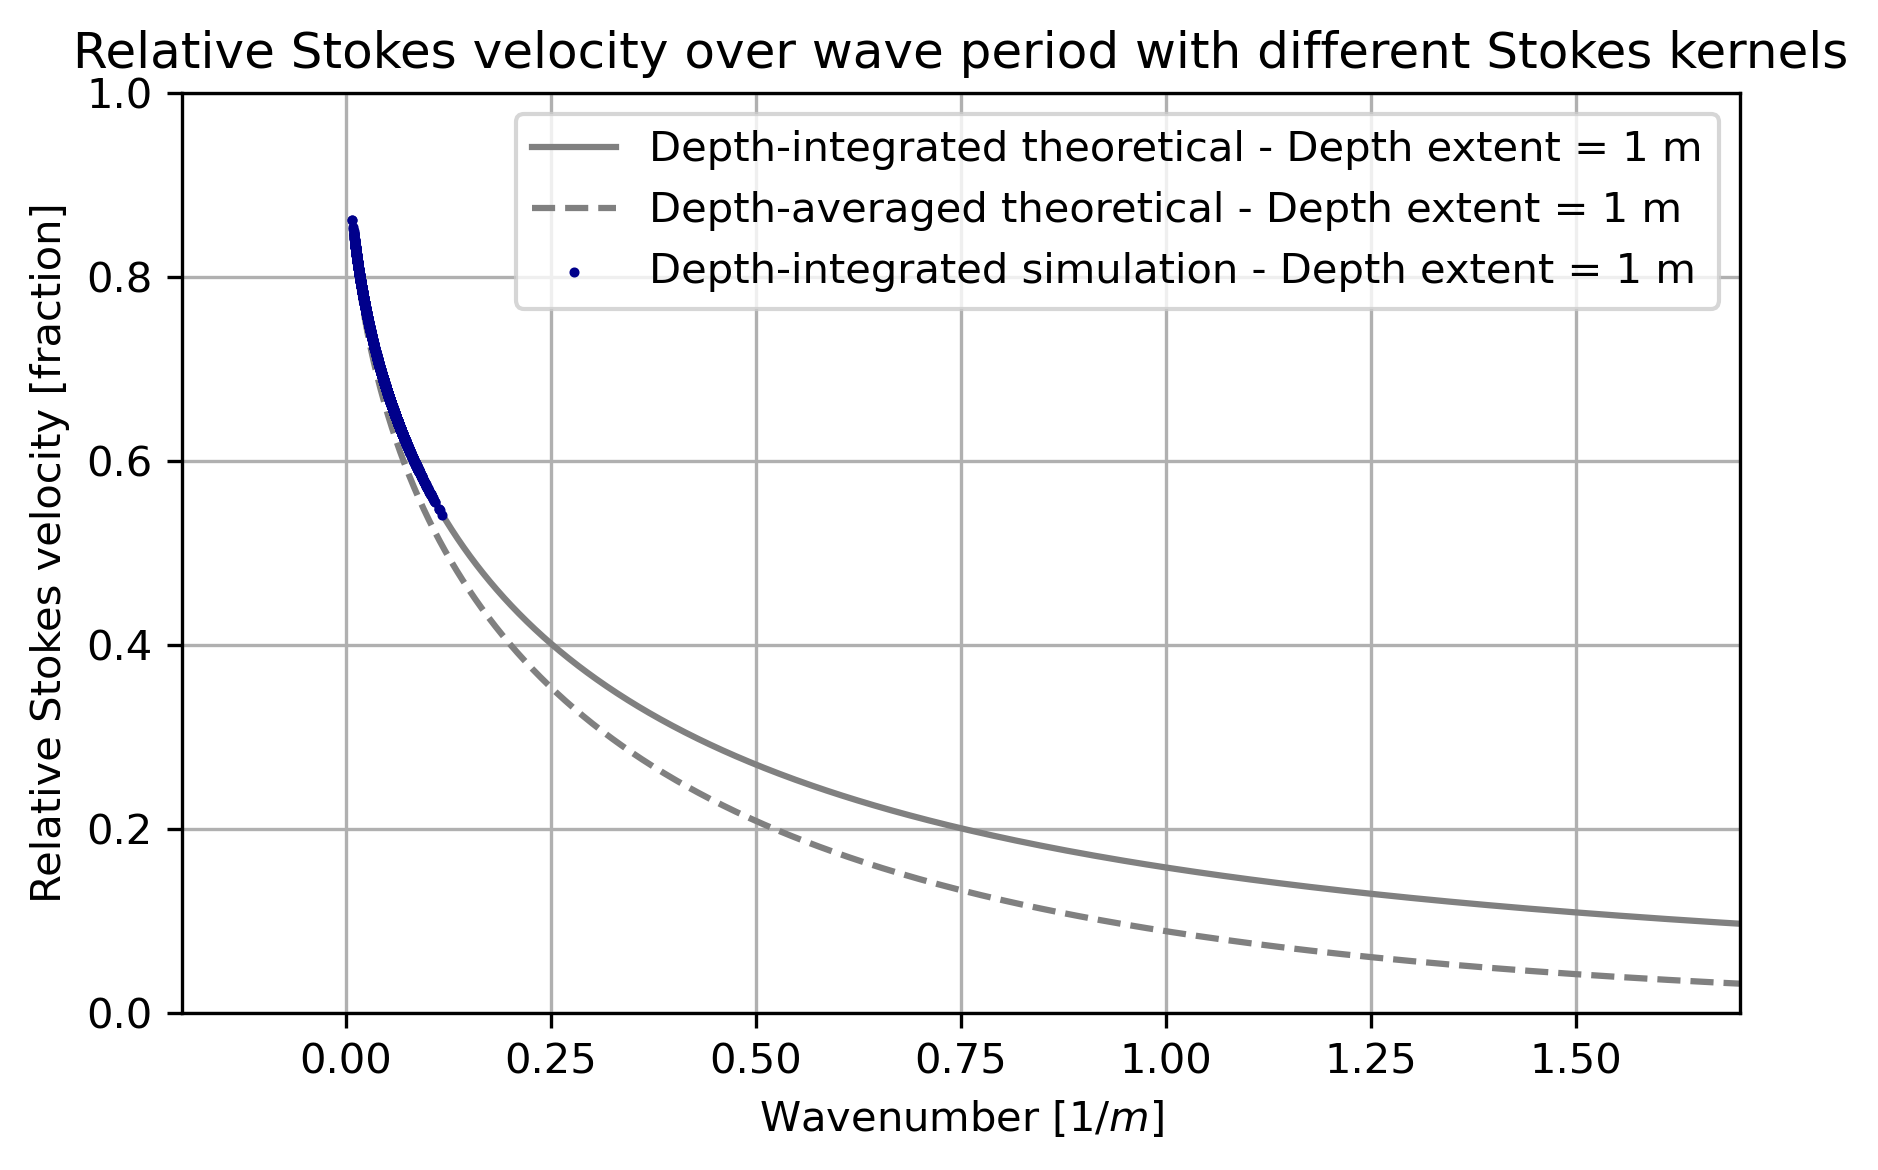

In [16]:
#CHECKING AGAIN
z = 0
pd = 1 #particle depth extent
pd2 = 0.5
T_p = np.arange(0,20,0.01)
delta_z = 1

#BOTH
omega_p = 2. * math.pi / T_p

#Peak wave number
k_p = (omega_p ** 2) / 9.81

#DEPTH AVERAGED
kp_z_2 = 2. * k_p * pd / 2
kp_z_22 = 2. * k_p * pd2 / 2

# Decay factor in Eq. (19) -- Where beta=1 for the Phillips spectrum
decay_averaged = np.exp(-kp_z_2) - np.sqrt(np.pi * kp_z_2) * scipy.special.erfc(np.sqrt(kp_z_2))
decay_averaged2 = np.exp(-kp_z_22) - np.sqrt(np.pi * kp_z_22) * scipy.special.erfc(np.sqrt(kp_z_22))


#Decay function lower extent, based on Equation A.6 of Li et al. (2017) 
decay_function_lower = 1/(2*k_p) * ( 
                    1 - np.exp(-2*k_p*(pd)) 
                    - 2/3 * (1 
                             + np.sqrt(np.pi) * (2*k_p*(pd))**(3/2) * scipy.special.erfc(np.sqrt(2*k_p*(pd)))  
                    - (1 + 2*k_p*(pd)) * np.exp(-2*k_p*(pd))   )
                    )
        
#Decay function upper extent, based on Equation A.6 of Li et al. (2017) 
decay_function_upper = 1/(2*k_p) * ( 
                    1 - np.exp(-2*k_p*(z)) 
                    - 2/3 * (1 + np.sqrt(np.pi) * (2*k_p*(z))**(3/2) * scipy.special.erfc(np.sqrt(2*k_p*(z)))  
                    - (1 + 2*k_p*(z)) * np.exp(-2*k_p*(z))   )
                    )
        
        # Saving decay function as particle variable
        #particle.decay_integrated_lower = decay_function_lower
        #particle.decay_integrated_upper = decay_function_upper
        
stokes_U = 1
stokes_V = 1
        #Integration function between surface and lower level based on Equation A.7 of Li et al. (2017)
stokes_U_av = (stokes_U * decay_function_lower - stokes_U * decay_function_upper) / ( delta_z)
stokes_V_av = (stokes_V * decay_function_lower - stokes_V * decay_function_upper) / ( delta_z)

wavenumbers =  ((2*np.pi / T_p) **2) / 9.81

fig, (ax1) = plt.subplots(1, 1, figsize=(6, 4), dpi = 300)

ax1.plot(wavenumbers, decay_function_lower, "-", label='Depth-integrated theoretical - Depth extent = 1 m', color = 'grey')
ax1.plot(wavenumbers, decay_averaged ,"--", label='Depth-averaged theoretical - Depth extent = 1 m', color = 'grey')
#ax1.plot(wavenumbers, decay_averaged2 ,"--", label='Depth-averaged theoretical - Depth extent = 0.5 m', color = 'darkkhaki')
ax1.scatter(DSX3.k_p.transpose(), DSX3.decay_integrated_lower.transpose() , c = 'darkblue', s = 2, zorder=3, label = 'Depth-integrated simulation - Depth extent = 1 m')
#ax1.plot(T_p2 , decay_stokes_vel2, "-" , label='Depth-integrated - T = 5 s', color = 'darkkhaki')
ax1.set_xlabel(r'Wavenumber [$1/m$]')
ax1.set_ylabel('Relative Stokes velocity [fraction]')
ax1.set_title('Relative Stokes velocity over wave period with different Stokes kernels')
ax1.grid()
ax1.set_xlim(-0.2, 1.7)
ax1.set_ylim(0,1)
ax1.legend(loc='upper right')
#ax1.vlines(1,0.3,1.1, color = 'peru')

plt.tight_layout()
plt.show()

0.95014364
0.6673852
[[1.4852114 1.4844381 1.4807426 ...       nan       nan       nan]
 [1.4699788 1.4655827 1.4687613 ...       nan       nan       nan]
 [1.5531032 1.5394027 1.5248966 ...       nan       nan       nan]
 ...
 [1.2720836 1.2768004 1.2822714 ...       nan       nan       nan]
 [1.2899729 1.2950343 1.3039415 ...       nan       nan       nan]
 [1.2694155 1.2704681 1.2729315 ...       nan       nan       nan]]


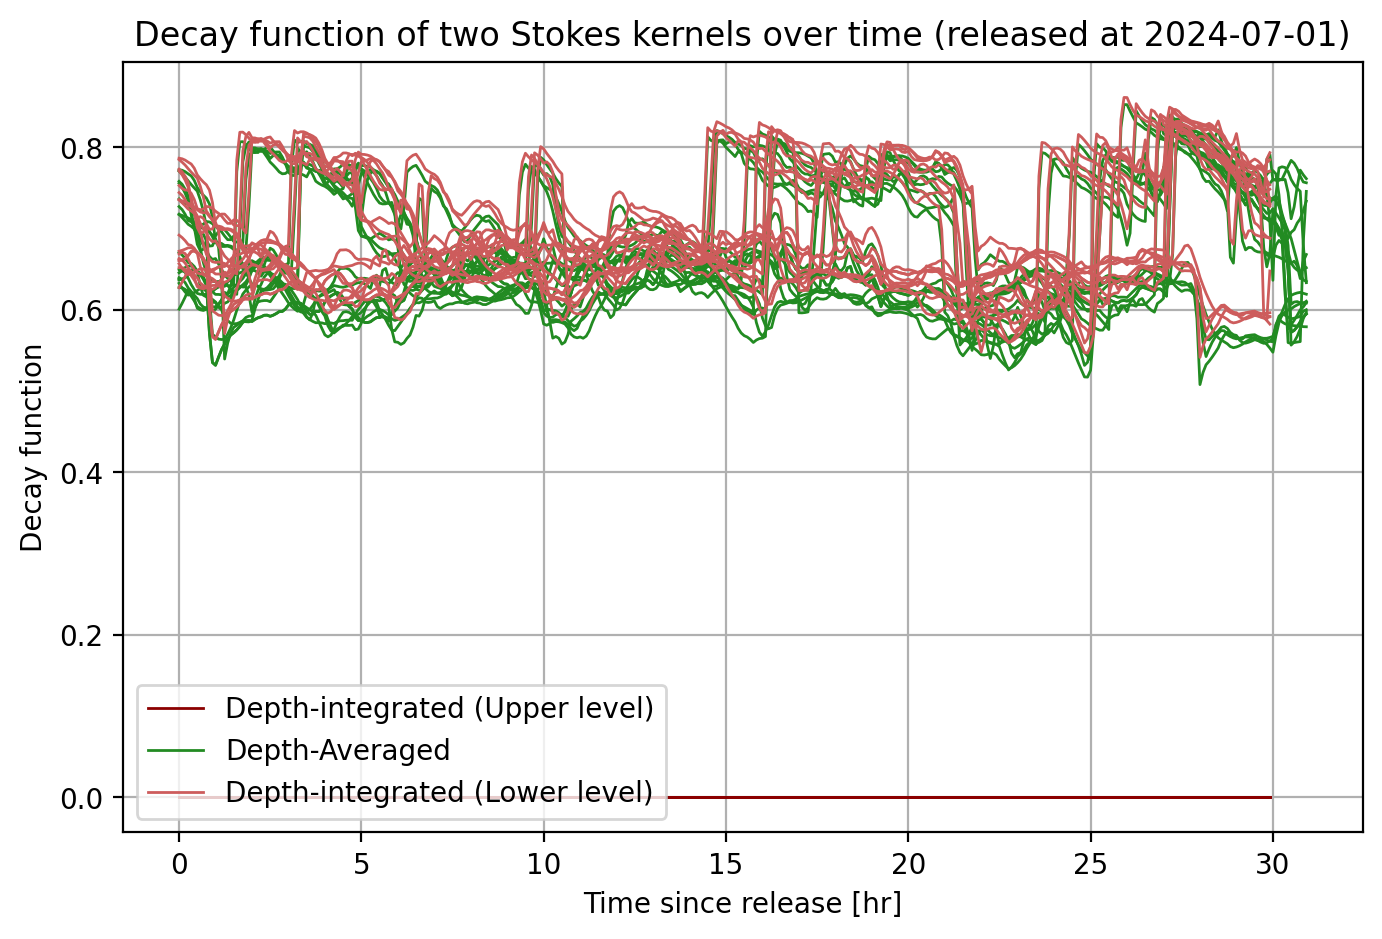

In [8]:
#Starttime definition
starttimejuly = datetime(2024,7,1)
starttimejan = datetime(2024,1,1)

#Definition of time array
time_in_hours = ((DSDDI['time']-DSDDI['time'][:,0]).astype("timedelta64[h]"))

time_in_days = ((DSDDI['time'] - DSDDI['time'][:, 0]).astype("timedelta64[h]")).astype(float) / 24

#Calculating average
DI_av = np.nanmean( DSDDI.decay_integrated_lower.values )
print(DI_av)
AV_av = np.nanmean( DSDAV.decay_averaged.values )
print(AV_av)

factor = DSDDI.decay_integrated_lower / DSDAV.decay_averaged
print(factor.values)

#Figure that shows sampled temperature of particle over time
figs = plt.figure(figsize = (8,5), dpi=200)
plt.plot(time_in_days.transpose(), DSX3.decay_integrated_upper.transpose() , c = 'darkred', linewidth = 1)
plt.plot(time_in_days[0,:].transpose(), DSX3.decay_integrated_upper[0,:].transpose(), c = 'darkred', label = r'Depth-integrated (Upper level)', linewidth = 1 )
plt.plot(time_in_days.transpose(), DSDAV.decay_averaged.transpose() ,  c = 'forestgreen', linewidth = 1)
plt.plot(time_in_days[0,:].transpose(), DSDAV.decay_averaged[0,:].transpose(), c = 'forestgreen', label = r'Depth-Averaged', linewidth = 1 )
plt.plot(time_in_days.transpose(), DSX3.decay_integrated_lower.transpose(), '-', c = 'indianred' , linewidth = 1)
plt.plot(time_in_days[0,:].transpose(), DSX3.decay_integrated_lower[0,:].transpose(), '-', c = 'indianred', label = r'Depth-integrated (Lower level)', linewidth = 1 )

plt.title(f'Decay function of two Stokes kernels over time (released at {starttimejuly.date()})')
plt.xlabel('Time since release [hr]')
plt.ylabel('Decay function')
#plt.ylim(23.5,30.2)
plt.legend(loc='lower left')
plt.grid()
plt.show()

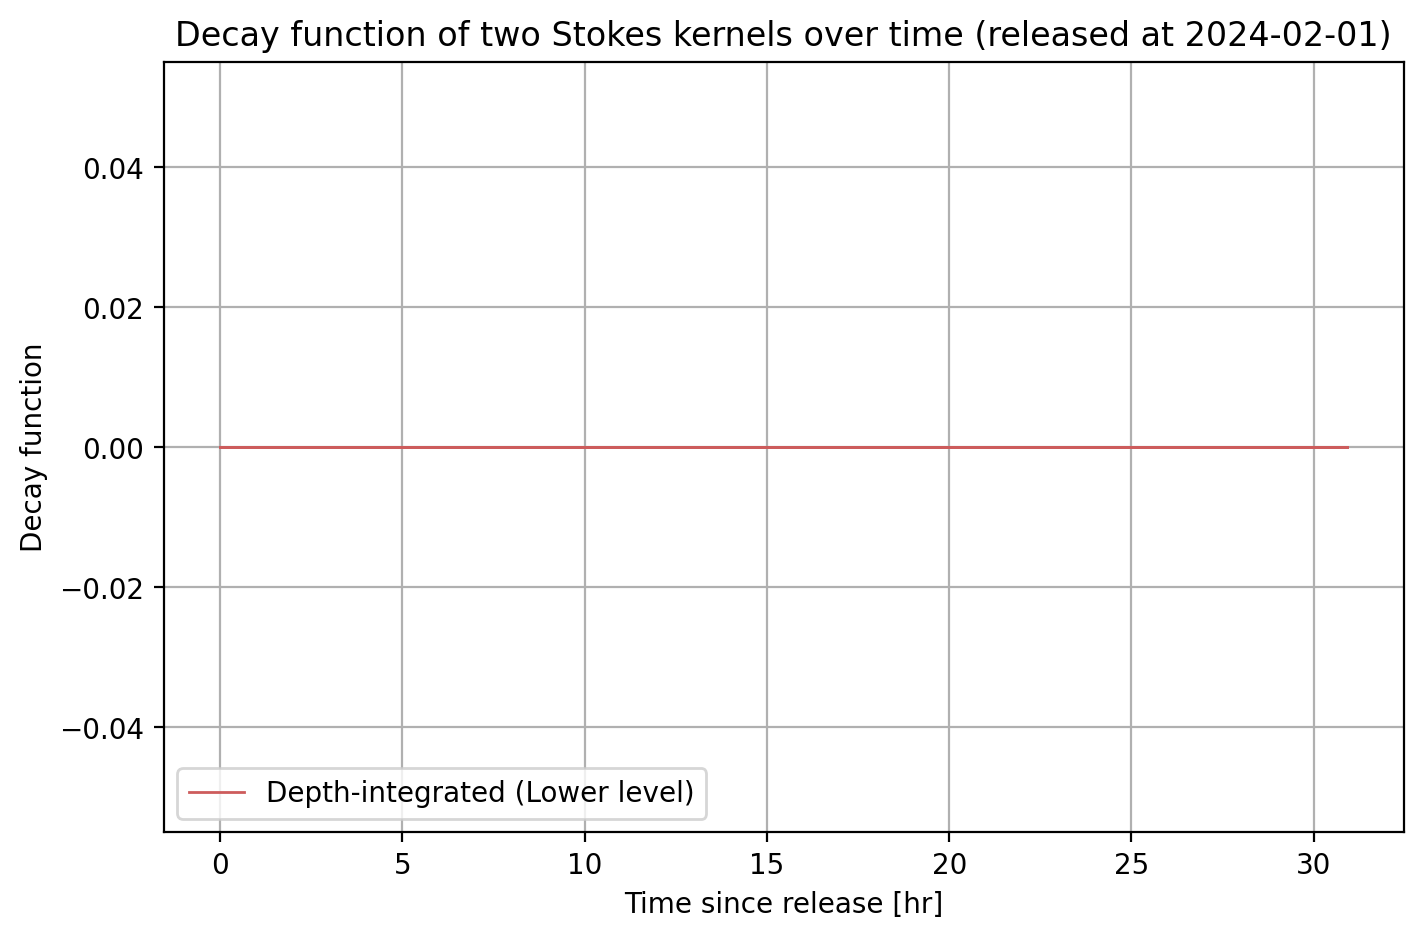

In [6]:
#Starttime definition
starttimefeb = datetime(2024,2,1)

#Definition of time array
time_in_hours = ((DSL2['time']-DSL2['time'][:,0]).astype("timedelta64[h]"))
time_in_days = ((DSL2['time'] - DSL2['time'][:, 0]).astype("timedelta64[h]")).astype(float) / 24

#Figure that shows sampled temperature of particle over time
figs = plt.figure(figsize = (8,5), dpi=200)
#plt.plot(time_in_days.transpose(), DSL2.decay_integrated_upper.transpose() , c = 'darkred', linewidth = 1)
#plt.plot(time_in_days[0,:].transpose(), DSL2.decay_integrated_upper[0,:].transpose(), c = 'darkred', label = r'Depth-integrated (Upper level)', linewidth = 1 )
#plt.plot(time_in_days.transpose(), DSL2.decay_averaged.transpose() ,  c = 'forestgreen', linewidth = 1)
#plt.plot(time_in_days[0,:].transpose(), DSL2.decay_averaged[0,:].transpose(), c = 'forestgreen', label = r'Depth-Averaged', linewidth = 1 )
plt.plot(time_in_days.transpose(), DSL2.decay_integrated_lower.transpose(), '-', c = 'indianred' , linewidth = 1)
plt.plot(time_in_days[0,:].transpose(), DSL2.decay_integrated_lower[0,:].transpose(), '-', c = 'indianred', label = r'Depth-integrated (Lower level)', linewidth = 1 )

plt.title(f'Decay function of two Stokes kernels over time (released at {starttimefeb.date()})')
plt.xlabel('Time since release [hr]')
plt.ylabel('Decay function')
#plt.ylim(23.5,30.2)
plt.legend(loc='lower left')
plt.grid()
plt.show()

[[ 0.  0.  0. ... nan nan nan]
 [ 0.  0.  0. ... nan nan nan]
 [ 0.  0.  0. ... nan nan nan]
 ...
 [ 0.  0.  0. ... nan nan nan]
 [ 0.  0.  0. ... nan nan nan]
 [ 0.  0.  0. ... nan nan nan]]
[[ 0.  0.  0. ... nan nan nan]
 [ 0.  0.  0. ... nan nan nan]
 [ 0.  0.  0. ... nan nan nan]
 ...
 [ 0.  0.  0. ... nan nan nan]
 [ 0.  0.  0. ... nan nan nan]
 [ 0.  0.  0. ... nan nan nan]]
[[ 1.  1.  1. ... nan nan nan]
 [ 1.  1.  1. ... nan nan nan]
 [ 1.  1.  1. ... nan nan nan]
 ...
 [ 1.  1.  1. ... nan nan nan]
 [ 1.  1.  1. ... nan nan nan]
 [ 1.  1.  1. ... nan nan nan]]
[[ 1.  1.  1. ... nan nan nan]
 [ 1.  1.  1. ... nan nan nan]
 [ 1.  1.  1. ... nan nan nan]
 ...
 [ 1.  1.  1. ... nan nan nan]
 [ 1.  1.  1. ... nan nan nan]
 [ 1.  1.  1. ... nan nan nan]]


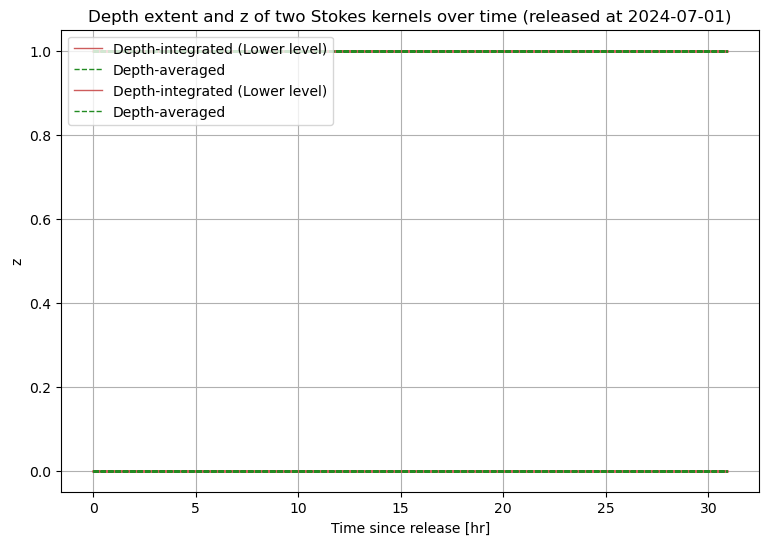

In [6]:
print(DSDDI.z.values)
print(DSDAV.z.values)

print(DSDDI.depth_extent.values)
print(DSDAV.depth_extent.values)

#Figure that shows sampled temperature of particle over time
figtemp = plt.figure(figsize = (9,6), dpi=100)

plt.plot(time_in_days.transpose(), DSDDI2.z.transpose(), '-', c = 'indianred' , linewidth = 1)
plt.plot(time_in_days[0,:].transpose(), DSDDI2.z[0,:].transpose(), '-', c = 'indianred', label = r'Depth-integrated (Lower level)', linewidth = 1 )
plt.plot(time_in_days.transpose(), DSDAV2.z.transpose(), '--', c = 'forestgreen' , linewidth = 1)
plt.plot(time_in_days[0,:].transpose(), DSDAV2.z[0,:].transpose(), '--', c = 'forestgreen', label = r'Depth-averaged', linewidth = 1 )

plt.plot(time_in_days.transpose(), DSDDI2.depth_extent.transpose(), '', c = 'indianred' , linewidth = 1)
plt.plot(time_in_days[0,:].transpose(), DSDDI2.depth_extent[0,:].transpose(), '', c = 'indianred', label = r'Depth-integrated (Lower level)', linewidth = 1 )
plt.plot(time_in_days.transpose(), DSDAV2.depth_extent.transpose(), '--', c = 'forestgreen' , linewidth = 1)
plt.plot(time_in_days[0,:].transpose(), DSDAV2.depth_extent[0,:].transpose(), '--', c = 'forestgreen', label = r'Depth-averaged', linewidth = 1 )

plt.title(f'Depth extent and z of two Stokes kernels over time (released at {starttimejuly.date()})')
plt.xlabel('Time since release [hr]')
plt.ylabel('z')
#plt.ylim(-0.01,0.41)
plt.legend(loc='upper left')
plt.grid()
plt.show()

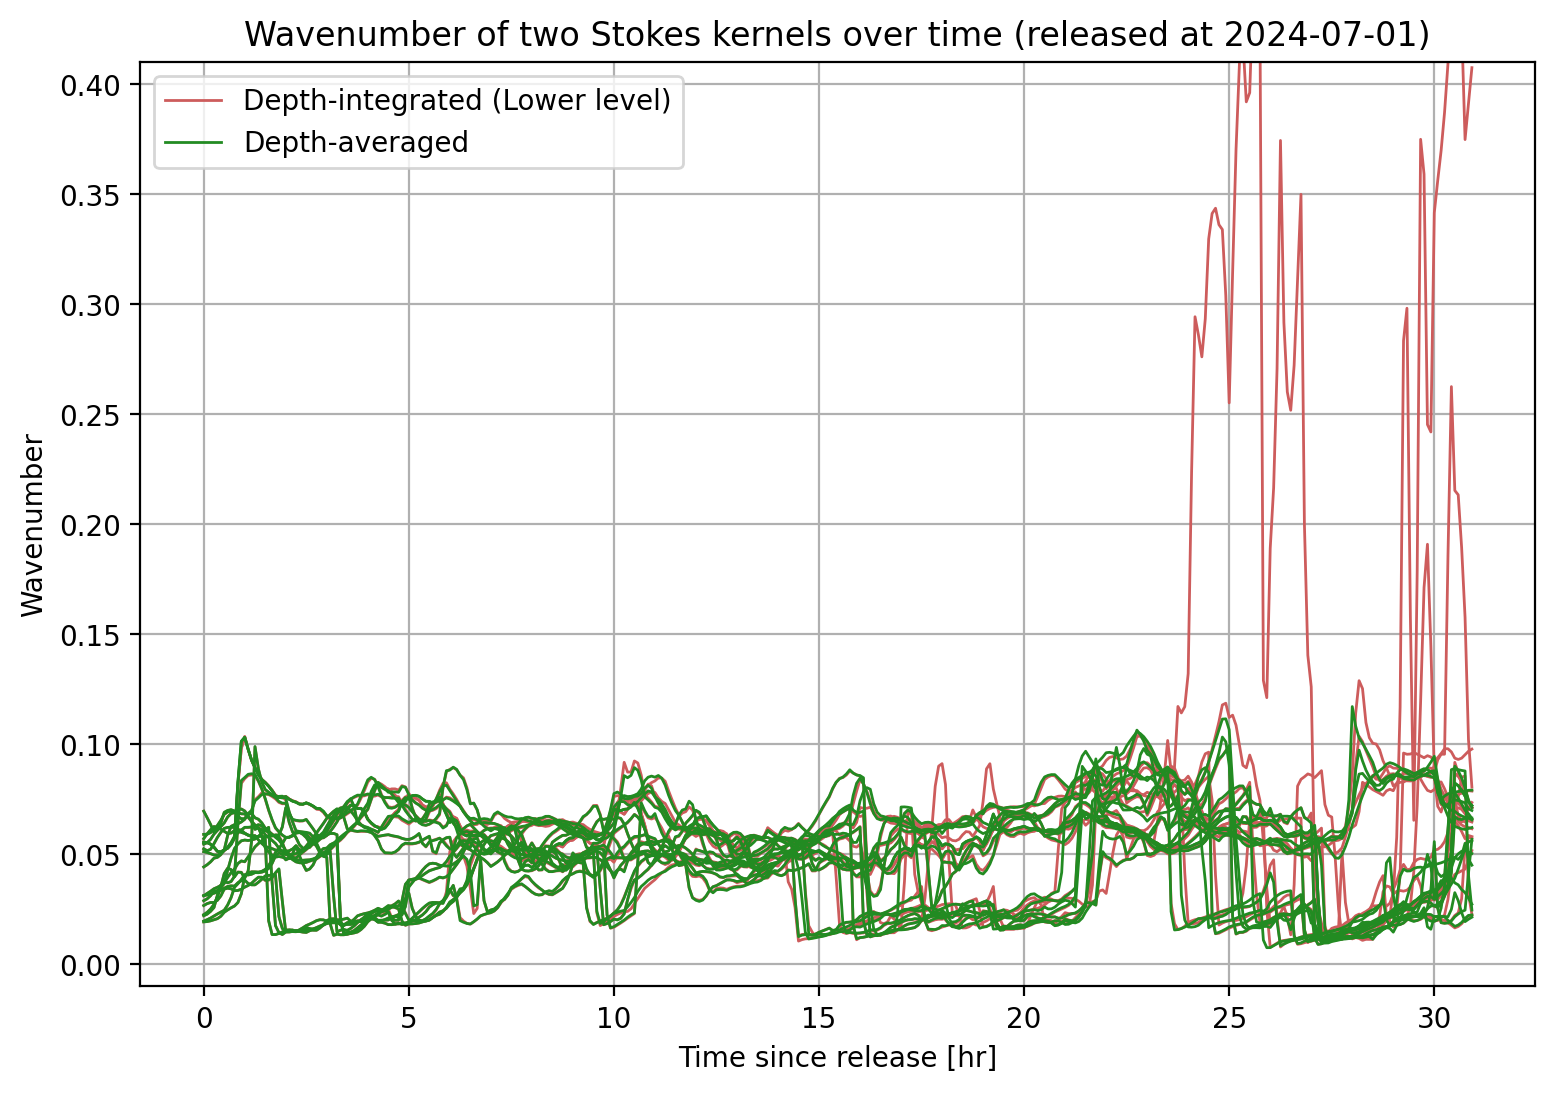

In [23]:
#Starttime definition
starttimejuly = datetime(2024,7,1)
starttimejan = datetime(2024,1,1)

#Definition of time array
time_in_hours = ((DSDDI['time']-DSDDI['time'][:,0]).astype("timedelta64[h]"))

time_in_days = ((DSDDI['time'] - DSDDI['time'][:, 0]).astype("timedelta64[h]")).astype(float) / 24


#Figure that shows sampled temperature of particle over time
figtemp = plt.figure(figsize = (9,6), dpi=200)

plt.plot(time_in_days.transpose(), DSDDI2.k_p.transpose(), '-', c = 'indianred' , linewidth = 1)
plt.plot(time_in_days[0,:].transpose(), DSDDI2.k_p[0,:].transpose(), '-', c = 'indianred', label = r'Depth-integrated (Lower level)', linewidth = 1 )
plt.plot(time_in_days.transpose(), DSDAV2.k_p.transpose(), '-', c = 'forestgreen' , linewidth = 1)
plt.plot(time_in_days[0,:].transpose(), DSDAV2.k_p[0,:].transpose(), '-', c = 'forestgreen', label = r'Depth-averaged', linewidth = 1 )

plt.title(f'Wavenumber of two Stokes kernels over time (released at {starttimejuly.date()})')
plt.xlabel('Time since release [hr]')
plt.ylabel('Wavenumber')
plt.ylim(-0.01,0.41)
plt.legend(loc='upper left')
plt.grid()
plt.show()

In [25]:
k_p_AV_average = np.nanmean( DSDAV2.k_p.values )
print(k_p_AV_average)

T_average = 2*np.pi / ( np.sqrt(k_p_AV_average*9.81))

print(T_average)

0.048894513
9.072256


In [26]:
#CHECKING EVERY TERM !!!!

k_p  = k_p_AV_average
depth_extent = 1
pd = 1

decay_function_lower = 1/(2*k_p) * ( 
                    1 - math.exp(-2*k_p*(depth_extent)) 
                    - 2/3 * (1 + math.sqrt(math.pi) * (2*k_p*(depth_extent))**(3/2) * math.erfc(math.sqrt(2*k_p*(depth_extent)))  
                    - (1 + 2*k_p*(depth_extent)) * math.exp(-2*k_p*(depth_extent))   )
                    )

term1 = 1/(2*k_p)
term2 = 1 - math.exp(-2*k_p*(depth_extent))
term3 = 1 + math.sqrt(math.pi) * (2*k_p*(depth_extent))**(3/2) * math.erfc(math.sqrt(2*k_p*(depth_extent)))
term4 = (1 + 2*k_p*(depth_extent)) * math.exp(-2*k_p*(depth_extent))

decay_integrated = term1 * (term2 - 2/3 * ( term3 - term4 )             
                            )  

print('Values of the terms: ', term1, term2, term3, term4, ' Integrated decay value: ', decay_integrated, decay_function_lower)


#Decay function lower extent, based on Equation A.6 of Li et al. (2017) 
decay_function_lower_aangepast = 1/(2*k_p) * ( 
                    1 - np.exp(-2*k_p*(pd)) 
                    - 2/3 * (1 + np.sqrt(np.pi) * (2*k_p*(pd))**(3/2) * scipy.special.erfc(np.sqrt(2*k_p*(pd)))  
                    - (1 + 2*k_p*(pd)) * np.exp(-2*k_p*(pd))   )
                    )

term5 = 1/(2*k_p)
term6 = 1 - np.exp(-2*k_p*(pd))
term7 = 1 + np.sqrt(np.pi) * (2*k_p*(pd))**(3/2) * scipy.special.erfc(np.sqrt(2*k_p*(pd)))
term8 = (1 + 2*k_p*(pd)) * np.exp(-2*k_p*(pd)) 

decay_integrated_aangepast = term5 * (term6 - 2/3 * ( term7 - term8 )             
                            ) 

print('Values of the terms: ', term5, term6, term7, term8, ' Integrated decay value: ', decay_integrated_aangepast, decay_function_lower_aangepast)


#Averaged decay

kp_z_2 = 2. * k_p * depth_extent / 2


# Decay factor in Eq. (19) -- Where beta=1 for the Phillips spectrum
decay = math.exp(-kp_z_2) - math.sqrt(math.pi * kp_z_2) * math.erfc(math.sqrt(kp_z_2))

print('Averaged decay value: ', decay)

Values of the terms:  10.226096 0.09315979744394154 1.0356815 0.9955192  Integrated decay value:  0.6788589 0.6788589
Values of the terms:  10.226096 0.093159795 1.0356815123137406 0.9955192  Integrated decay value:  0.6788587163466709 0.6788587163466709
Averaged decay value:  0.6565730865162934


ValueError: x and y must have same first dimension, but have shapes (400, 3536) and (200, 16)

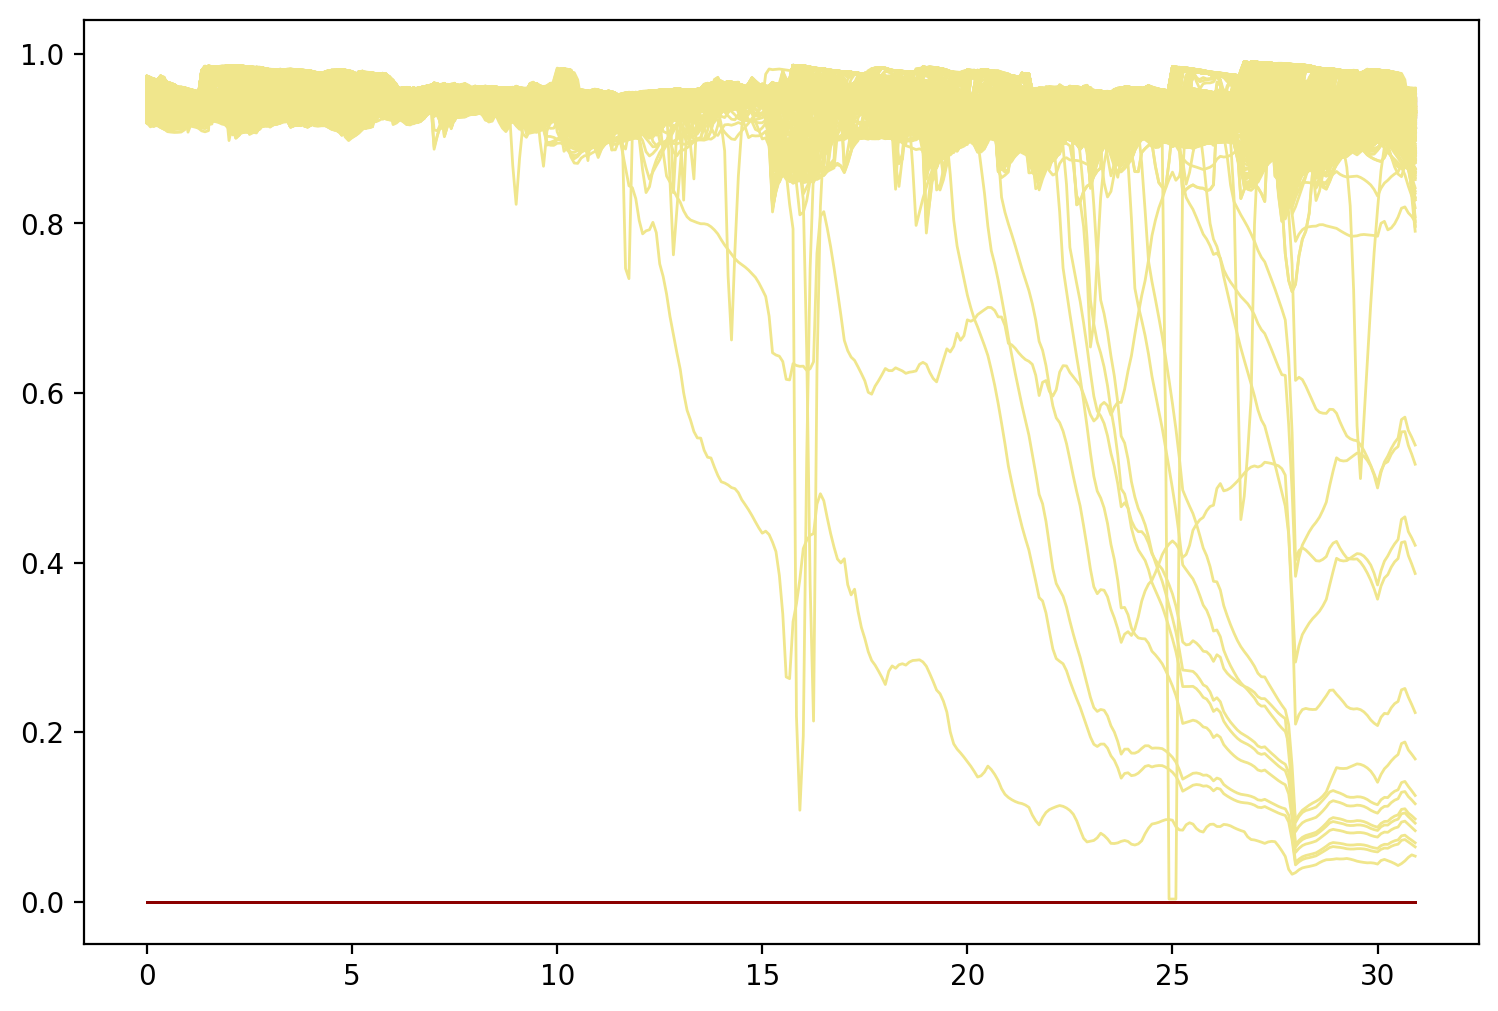

In [ ]:
#Opening simulation data file with new release locations
DSL = xr.open_zarr("/storage/shared/oceanparcels/output_data/data_Elena/Simulations_part2/SIM_1sept_newreleaseloc.zarr")
DSLA = xr.open_zarr("/storage/shared/oceanparcels/output_data/data_Elena/Simulations_part2/SIM_8sept_newgrid.zarr")
DSLAD = xr.open_zarr("/storage/shared/oceanparcels/output_data/data_Elena/Simulations_part2/SIM_9sept_newgrid_di.zarr")
DSX = xr.open_zarr("/storage/shared/oceanparcels/output_data/data_Elena/Simulations_part2/SIM_11sept_di_check.zarr")

#Definition of time array
time_in_hours = ((DSLA['time']-DSLA['time'][:,0]).astype("timedelta64[h]"))
time_in_days = ((DSLA['time'] - DSLA['time'][:, 0]).astype("timedelta64[h]")).astype(float) / 24


#Figure that shows sampled temperature of particle over time
figtemp = plt.figure(figsize = (9,6), dpi=200)
plt.plot(time_in_days.transpose(), DSX.decay_integrated_upper.transpose() , c = 'darkred', linewidth = 1)
plt.plot(time_in_days[0,:].transpose(), DSX.decay_integrated_upper[0,:].transpose(), c = 'darkred', label = r'Depth-integrated (Upper level)', linewidth = 1 )
plt.plot(time_in_days.transpose(), DSX.decay_integrated_lower.transpose(), c = 'indianred' , linewidth = 1)
plt.plot(time_in_days[0,:].transpose(), DSX.decay_integrated_lower[0,:].transpose(), c = 'indianred', label = r'Depth-integrated (Lower level)', linewidth = 1 )
plt.plot(time_in_days.transpose(), DSLA.decay_averaged.transpose() ,  c = 'forestgreen', linewidth = 1)
plt.plot(time_in_days[0,:].transpose(), DSLA.decay_averaged[0,:].transpose(), c = 'forestgreen', label = r'Depth-Averaged', linewidth = 1 )

plt.title(f'Decay function of two Stokes kernels over time (released at {starttimejuly.date()})')
plt.xlabel('Time since release [hr]')
plt.ylabel('Decay function')
#plt.ylim(23.5,30.2)
plt.legend(loc='lower left')
plt.grid()
plt.show()

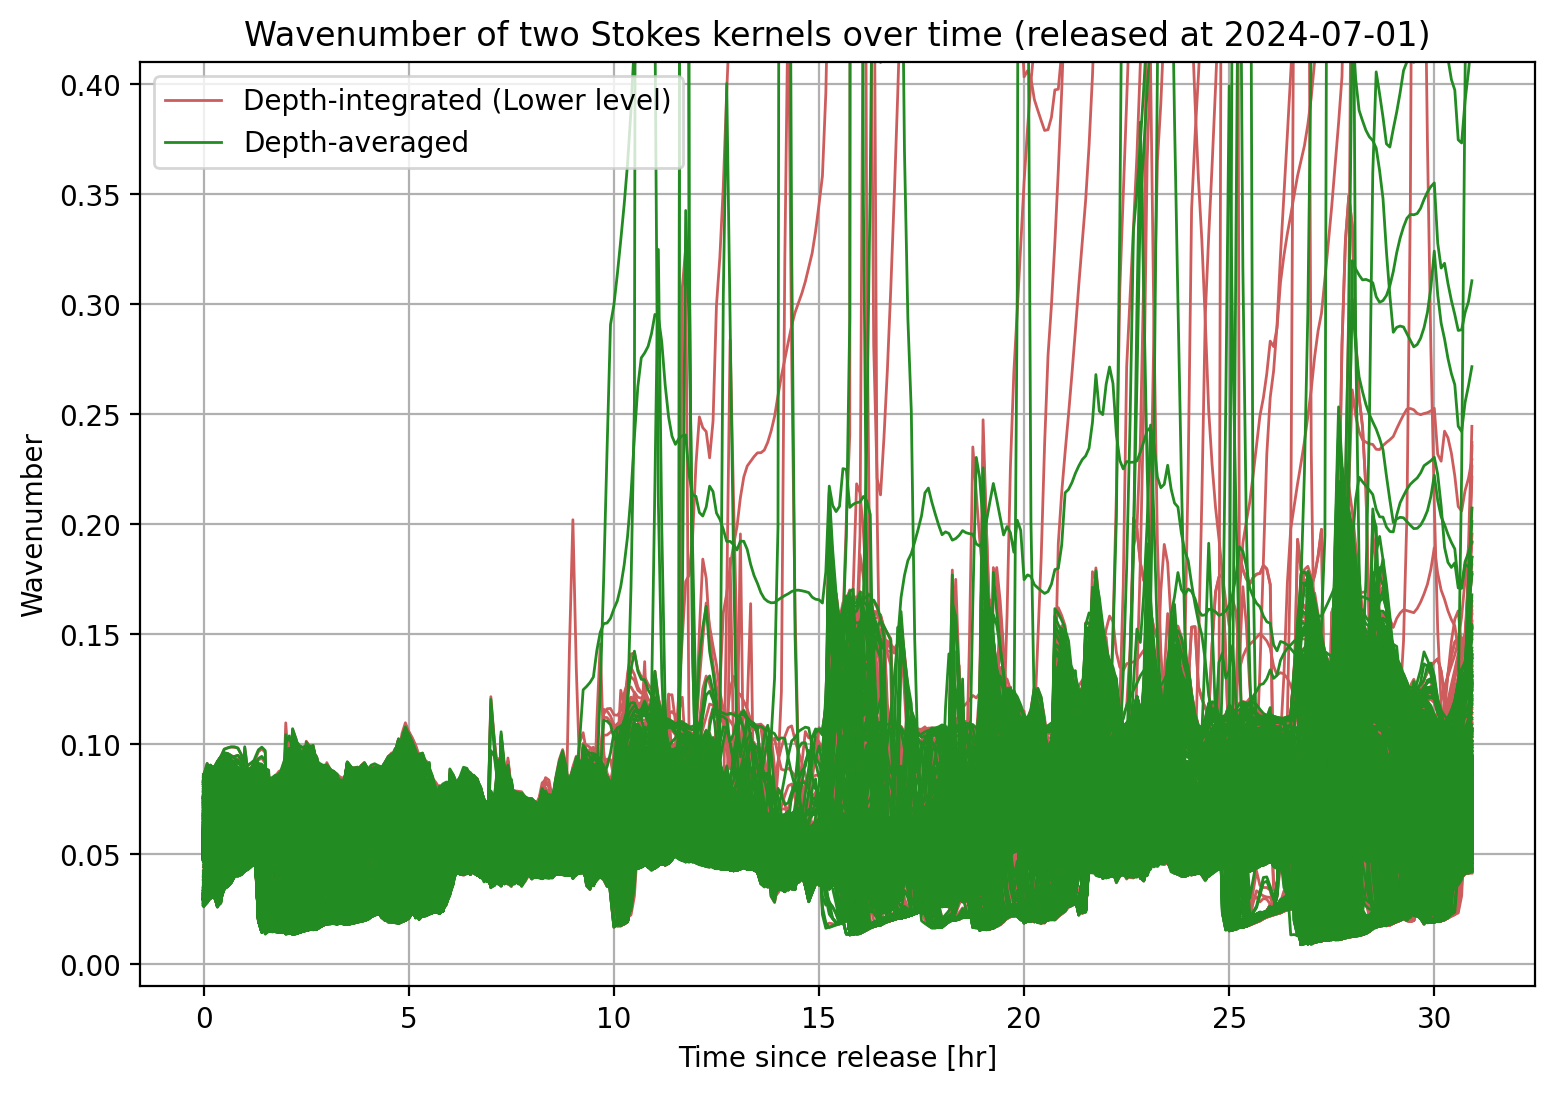

In [29]:
fig = plt.figure(figsize = (9,6), dpi=200)

plt.plot(time_in_days.transpose(), DSLAD.k_p.transpose(), '-', c = 'indianred' , linewidth = 1)
plt.plot(time_in_days[0,:].transpose(), DSLAD.k_p[0,:].transpose(), '-', c = 'indianred', label = r'Depth-integrated (Lower level)', linewidth = 1 )
plt.plot(time_in_days.transpose(), DSLA.k_p.transpose(), '-', c = 'forestgreen' , linewidth = 1)
plt.plot(time_in_days[0,:].transpose(), DSLA.k_p[0,:].transpose(), '-', c = 'forestgreen', label = r'Depth-averaged', linewidth = 1 )

plt.title(f'Wavenumber of two Stokes kernels over time (released at {starttimejuly.date()})')
plt.xlabel('Time since release [hr]')
plt.ylabel('Wavenumber')
plt.ylim(-0.01,0.41)
plt.legend(loc='upper left')
plt.grid()
plt.show()